# **Task 1 - Exploratory Data Analysis on Retail Sales Data**

**Objective:** Perform a thorough Exploratory Data Analysis (EDA) on a retail sales dataset to uncover sales patterns, customer behaviour trends, product performances, and actionable business insights.


## 1. Import Required Libraries

We begin by importing the Python libraries required for data manipulation, statistical analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load the dataset

The csv file is loaded into a pandas DataFrame for further analysis

In [3]:
file_path = r"C:\Users\HP\OneDrive\Documents\GitHub\OIBSIP\DataAnalytics-L1-Task1-EDARetailSales\customer_segmentation_py.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 113,036
Columns: 18


## 3. Initial Dataset Inspection

We inspect the dataset structure, dimensions, column names, data types, and the first few records. This helps us understand what information is available before performing any analysis

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape: (113036, 18)

Column Names:
['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']

Data Types:


,Data Type
Date,str
Day,int64
Month,str
Year,int64
Customer_Age,int64
Age_Group,str
Customer_Gender,str
Country,str
State,str
Product_Category,str



First 5 Rows:


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26-11-2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26-11-2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23-03-2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23-03-2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15-05-2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418



Last 5 Rows:


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
113031,12-04-2016,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,02-04-2014,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,02-04-2016,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,04-03-2014,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260
113035,04-03-2016,4,March,2016,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",23,24,64,655,552,1207


### Observation

The dataset contains **113,036 rows and 18 columns**. It includes transaction dates, customer demographics, geographic information, product details, quantity, cost, price, profit, and revenue. This provides sufficient information for the required retail sales EDA.

## 4. Data quality Check - Missing Values and Duplicates

Before analysis, we check for missing values and duplicate records. Duplicate rows can distort totals and statistical results, so exact duplicate records are removed after inspection.

In [5]:
# Missing-value check
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing Values by Column:")
display(missing_values.to_frame("Missing Values"))

# Duplicate check
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")

# Remove exact duplicates
df = df.drop_duplicates().copy()

print(f"\nShape after removing duplicates: {df.shape}")

Missing Values by Column:


,Missing Values
Date,0
Day,0
Month,0
Year,0
Customer_Age,0
Age_Group,0
Customer_Gender,0
Country,0
State,0
Product_Category,0


Number of duplicate rows: 1,000

Shape after removing duplicates: (112036, 18)


### Observation

There are **no missing values** in any column. The dataset contains **1,000 exact duplicate rows**, which are removed before analysis to avoid double-counting sales and customer information. After cleaning, **112,036 unique rows** remain.

## 5. Data Type Conversion and Feature Preparation

In [6]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Create quarter feature
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

# Create month number for chronological sorting
df["Month_Number"] = df["Date"].dt.month

print("\nDate range:")
print(df["Date"].min().date(), "to", df["Date"].max().date())

print("\nUpdated data types:")
display(df[["Date", "Quarter", "Month_Number"]].dtypes.to_frame("Data Type"))


Date range:
2011-01-01 to 2016-07-31

Updated data types:


,Data Type
Date,datetime64[us]
Quarter,str
Month_Number,int32


### Observation 

The transaction dates range from **January 2011 to July 2016**. The date conversion was successful, and quarterly information has been created for time-series analysis.

## 6. Descriptive Statistics for Numerical Columns

The following table calculates the **mean, median, mode, and standard deviation** for every numerical variable in the cleaned dataset.

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

display(descriptive_stats)

,Mean,Median,Mode,Standard Deviation
Day,15.67,16.00,24,8.78
Year,"2,014.40","2,014.00",2016,1.27
Customer_Age,35.92,35.00,31,11.02
Order_Quantity,11.90,10.00,1,9.56
Unit_Cost,267.82,9.00,2,550.22
Unit_Price,453.85,25.00,5,922.75
Profit,286.04,103.00,3,454.85
Cost,471.10,112.00,1252,886.97
Revenue,757.14,226.00,35,"1,312.06"
Month_Number,6.45,6.00,6,3.48


### Observation

The descriptive statistics show that customer age is centered around **36 years**, while the median order quantity is **10 units**. Revenue has a substantially larger standard deviation than its median, indicating considerable variation in transaction value. The large difference between the mean and median for variables such as unit cost, unit price, cost, profit, and revenue also suggests that the sales data is right-skewed, with some high-value transactions.

## 7. Monthly Sales Trend

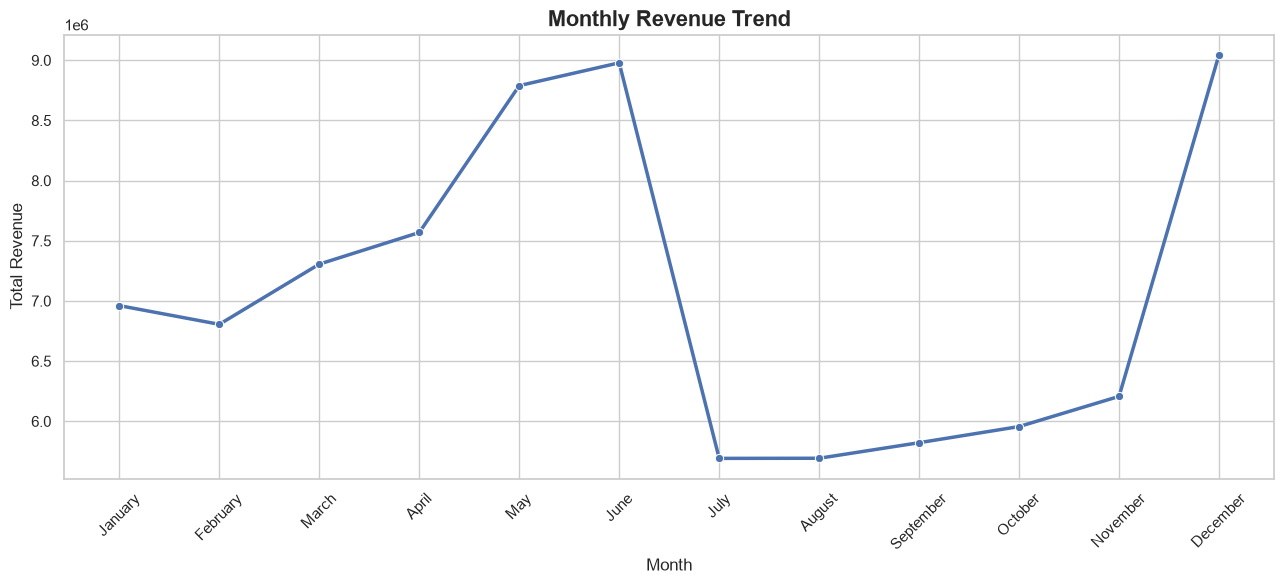

In [11]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(13, 6))
sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    linewidth=2.5
)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Revenue is strongest in **December**, followed by **June** and **May**. Revenue is comparatively lower during **July through October**. This indicates a seasonal pattern, with stronger sales toward the middle and end of the calendar year. The business can use this pattern to plan inventory and promotional campaigns in advance.

## 8. Quarterly Sales Trend

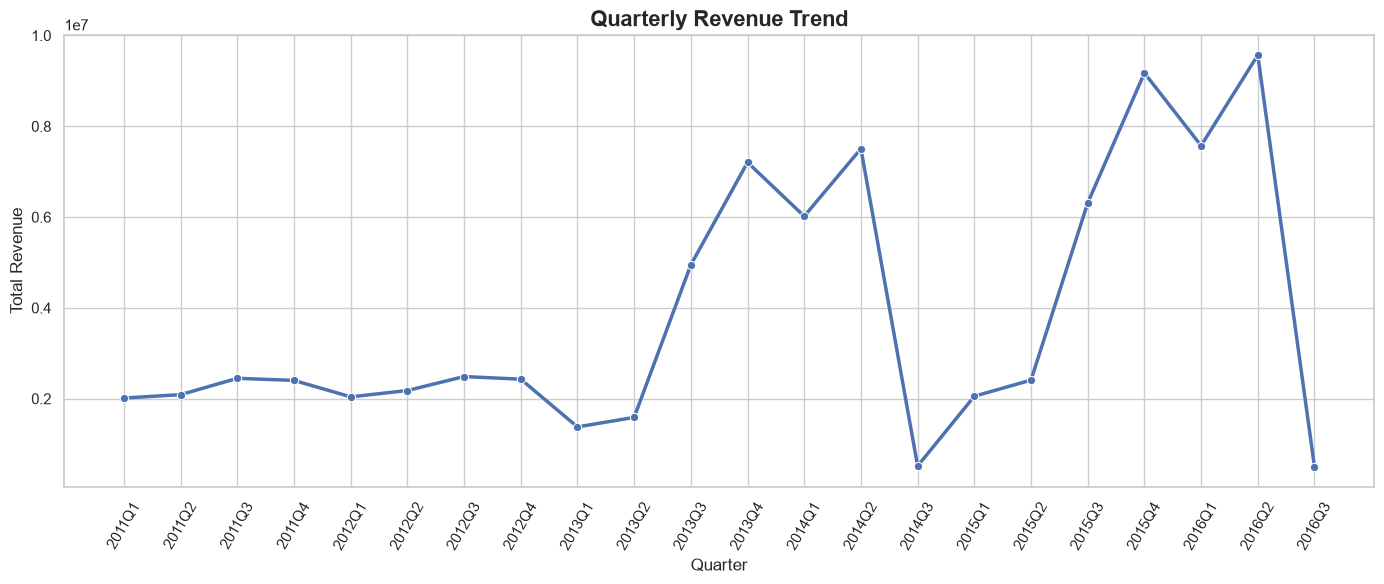

Top 5 quarters by revenue:


,Revenue
Quarter,
2016Q2,9567480
2015Q4,9174106
2016Q1,7571885
2014Q2,7506162
2013Q4,7204621


In [12]:
quarterly_sales = (
    df.groupby("Quarter")["Revenue"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    x=quarterly_sales.index,
    y=quarterly_sales.values,
    marker="o",
    linewidth=2.5
)

plt.title("Quarterly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

print("Top 5 quarters by revenue:")
display(quarterly_sales.sort_values(ascending=False).head(5).to_frame("Revenue"))

### Observation

Quarterly revenue varies substantially across the period. **2016 Q2 records the highest revenue**, followed by **2015 Q4**. The final quarter of 2016 is not present because the dataset ends in July 2016, so that period should not be interpreted as a complete quarter. The results suggest that the business experiences strong performance during selected quarters rather than following a perfectly consistent upward trend.

## 9. Customer Demographics - Age group Distribution

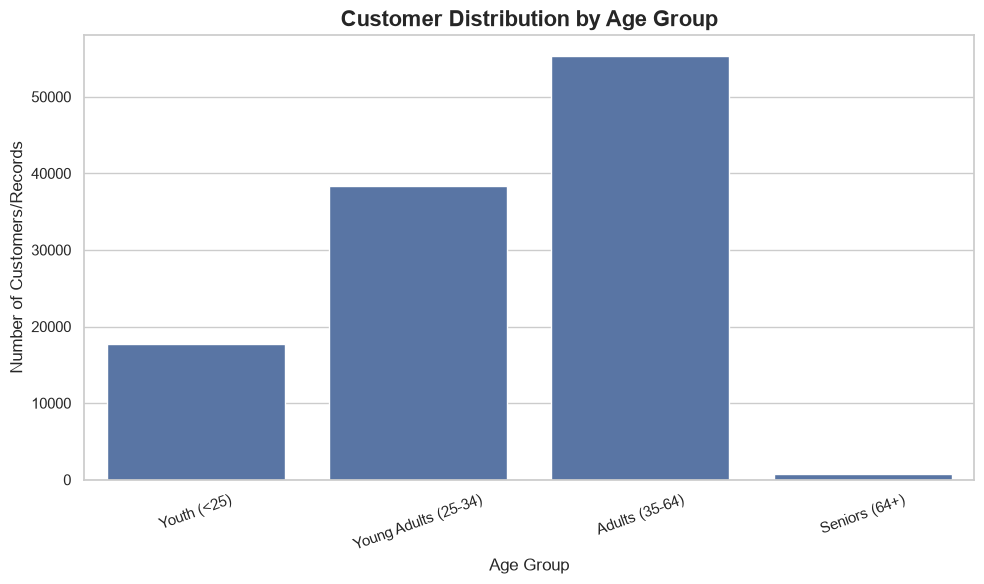

In [13]:
age_group_counts = df["Age_Group"].value_counts()

age_group_order = [
    "Youth (<25)",
    "Young Adults (25-34)",
    "Adults (35-64)",
    "Seniors (64+)"
]

age_group_counts = age_group_counts.reindex(age_group_order).dropna()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Customer Distribution by Age Group", fontsize=16, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers/Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Observation

The **Adults (35–64)** group has the largest representation, followed by **Young Adults (25–34)** and **Youth (<25)**. The **Seniors (64+)** group represents a very small share of the dataset. This suggests that marketing efforts should primarily address the adult and young-adult customer segments while using more targeted campaigns for seniors.

## 10. Customer Demographics - Gender Breakdown

Revenue is compared between male and female customers to understand whether sales performance differs meaningfully by gender.

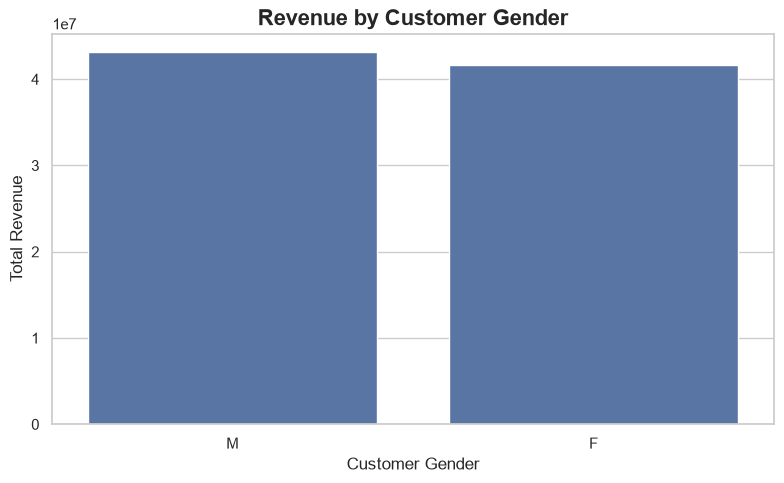

Revenue by gender:


,Revenue
Customer_Gender,
M,43132083
F,41694689


In [14]:
gender_revenue = (
    df.groupby("Customer_Gender")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=gender_revenue.index,
    y=gender_revenue.values
)

plt.title("Revenue by Customer Gender", fontsize=16, fontweight="bold")
plt.xlabel("Customer Gender")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

print("Revenue by gender:")
display(gender_revenue.to_frame("Revenue"))

### Observation

Male customers generate slightly higher total revenue than female customers, but the difference is relatively modest. This suggests that the business should avoid relying on gender as the primary segmentation variable and should instead combine demographic information with product and purchasing behaviour.

## 11. Product Analysis - Top 10 Best-Selling Products

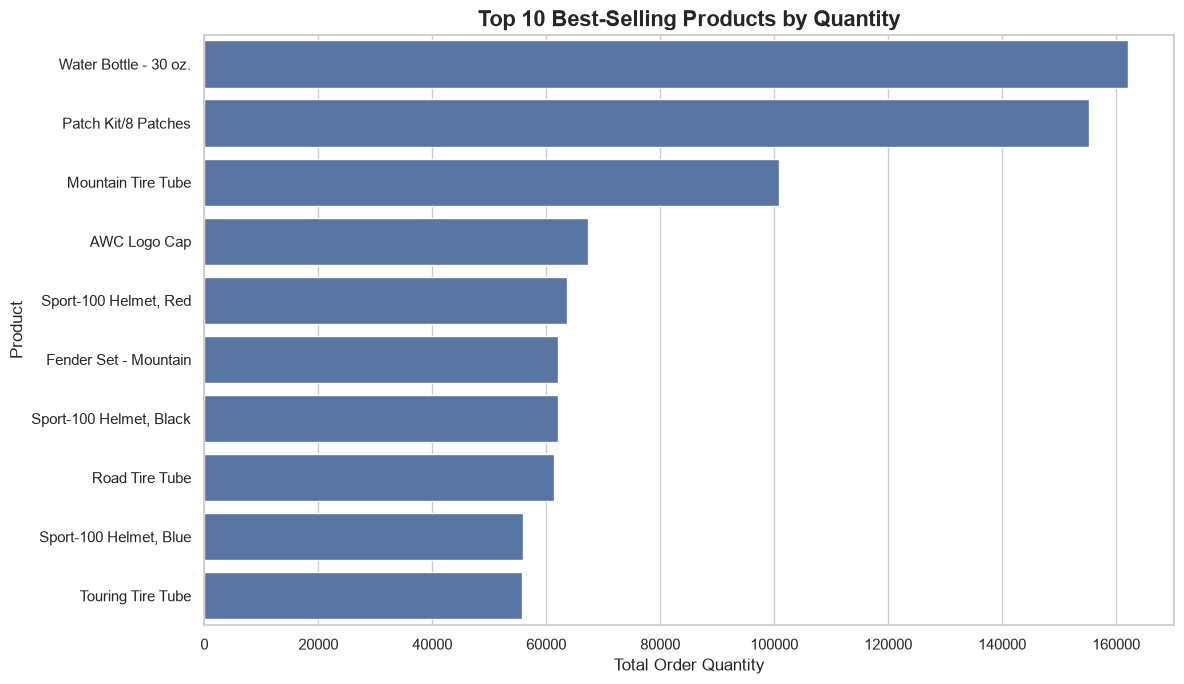

,Total Order Quantity
Product,
Water Bottle - 30 oz.,162051
Patch Kit/8 Patches,155310
Mountain Tire Tube,100915
AWC Logo Cap,67316
"Sport-100 Helmet, Red",63652
Fender Set - Mountain,62118
"Sport-100 Helmet, Black",62072
Road Tire Tube,61305
"Sport-100 Helmet, Blue",55855


In [15]:
top_10_products = (
    df.groupby("Product")["Order_Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title("Top 10 Best-Selling Products by Quantity", fontsize=16, fontweight="bold")
plt.xlabel("Total Order Quantity")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

display(top_10_products.to_frame("Total Order Quantity"))

### Observation

**Water Bottle - 30 oz.** is the best-selling product by quantity, followed by **Patch Kit/8 Patches** and **Mountain Tire Tube**. Several of the leading products are accessories or smaller replacement items, suggesting strong demand for frequently purchased complementary products. These items should receive careful inventory monitoring to reduce the risk of stock-outs.

## 12. Product Analysis - Revenue by Product Category

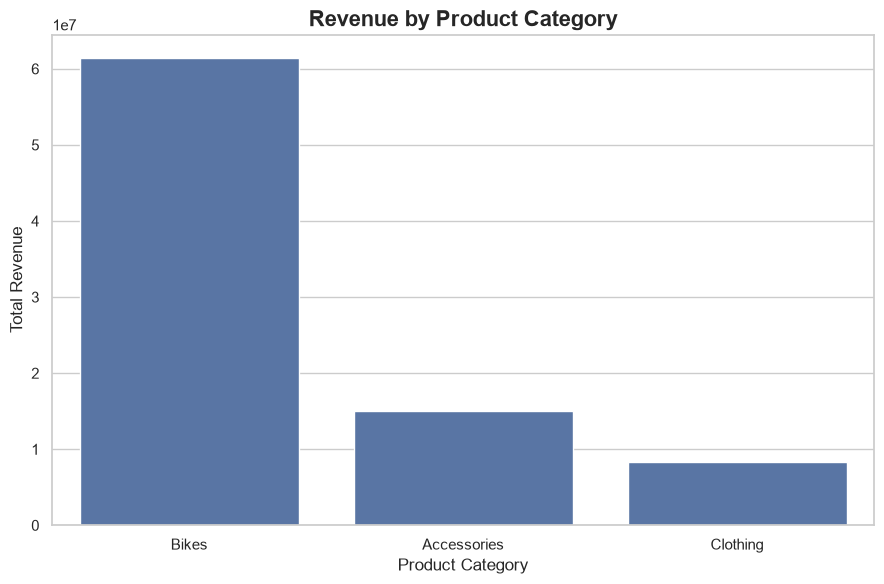

,Revenue
Product_Category,
Bikes,61434484
Accessories,15022766
Clothing,8369522


In [16]:
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

display(category_revenue.to_frame("Revenue"))

### Observation

**Bikes** generate by far the highest total revenue, contributing substantially more than Accessories and Clothing. This indicates that Bikes are the core revenue driver of the business. At the same time, Accessories generate considerably less revenue but can be strategically important as complementary products for cross-selling.

## 13. Correlation Heatmap


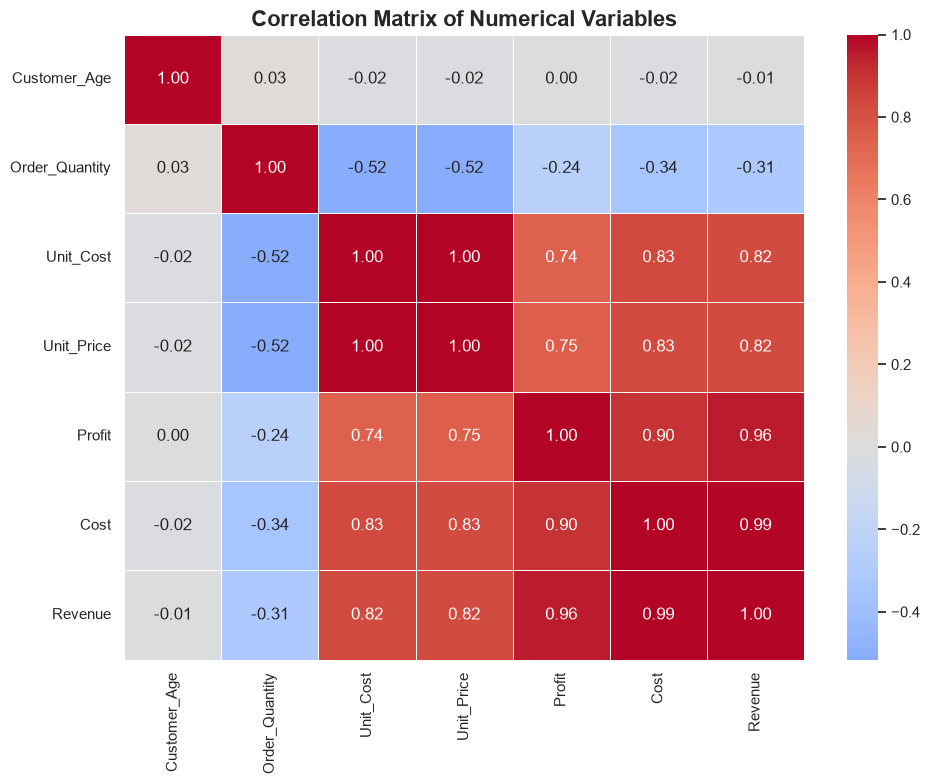

In [17]:
correlation_columns = [
    "Customer_Age",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Profit",
    "Cost",
    "Revenue"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

Revenue has a **very strong positive correlation with Cost (about 0.99)** and a **strong positive correlation with Profit (about 0.96)**. Unit Price and Unit Cost also show positive relationships with revenue. Customer Age has almost no linear relationship with revenue, while Order Quantity has a moderate negative correlation with revenue in this dataset. This suggests that transaction value is influenced more strongly by financial/product-price variables than by customer age.

## 14. Additional Visualization - Profit Margin by Product Category

Profit margin is calculated as:

**Profit Margin (%) = Profit / Revenue × 100**

A category can have lower revenue but still be more profitable per unit of revenue, so this analysis adds another business perspective.

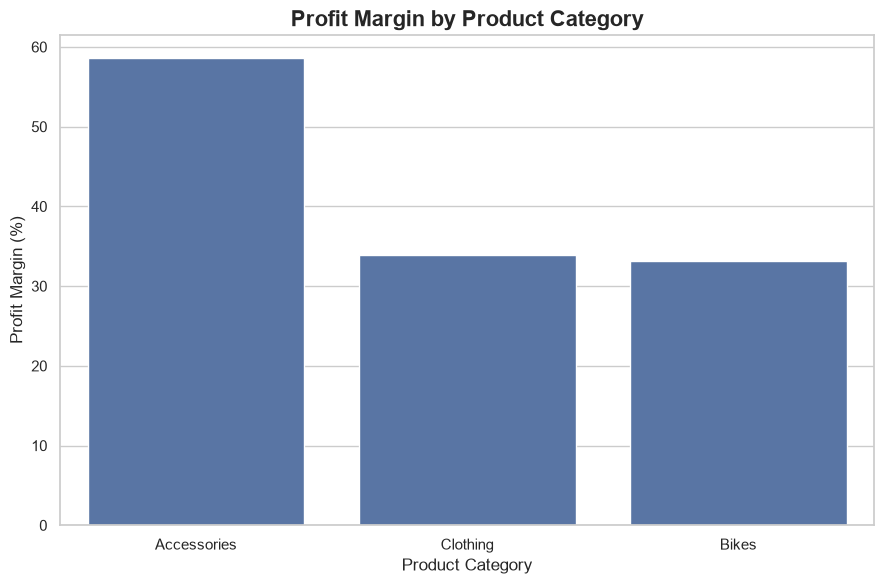

,Revenue,Profit,Profit_Margin_%
Product_Category,,,
Accessories,15022766,8807194,58.63
Clothing,8369522,2839319,33.92
Bikes,61434484,20399726,33.21


In [18]:
category_profitability = (
    df.groupby("Product_Category")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum")
      )
)

category_profitability["Profit_Margin_%"] = (
    category_profitability["Profit"] /
    category_profitability["Revenue"] * 100
)

category_profitability = category_profitability.sort_values(
    "Profit_Margin_%",
    ascending=False
)

plt.figure(figsize=(9, 6))
sns.barplot(
    x=category_profitability.index,
    y=category_profitability["Profit_Margin_%"].values
)

plt.title("Profit Margin by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

display(category_profitability.round(2))

### Observation

The additional analysis reveals an important difference between **revenue leadership and profitability efficiency**. Bikes generate the highest revenue, but Accessories have the highest profit margin at approximately **58.6%**, compared with about **33.2% for Bikes** and **33.9% for Clothing**. Therefore, Accessories may provide a stronger margin opportunity even though their total revenue is much smaller than Bikes.

## 15. Key Business Insights

Based on the EDA, the major findings are:

1. **Seasonality is visible in sales:** December has the highest aggregate monthly revenue, while July–October are comparatively weaker.
2. **Bikes are the primary revenue driver:** They generate substantially more revenue than Accessories and Clothing.
3. **Accessories are highly profitable:** Their profit margin is approximately 58.6%, much higher than the other major categories.
4. **Adults aged 35–64 are the largest customer group:** This segment represents the strongest demographic base in the dataset.
5. **A small set of products drives high sales volume:** Water Bottle - 30 oz. and Patch Kit/8 Patches are among the leading products by quantity.
6. **Revenue is strongly connected to financial variables:** Cost and Profit have very strong positive correlations with Revenue, while Customer Age has almost no linear correlation with Revenue.


## 16. Actionable Business Recommendations

### 1 — Prepare for Seasonal Demand
Increase inventory availability and launch targeted promotional campaigns before high-performing periods such as **May, June, and December**. During weaker months, use discounts, bundles, and seasonal campaigns to stimulate demand.

### 2 — Expand Accessory Cross-Selling
Accessories have the **highest profit margin** despite generating less total revenue than Bikes. The business should bundle accessories with bike purchases and promote complementary products such as bottles, tire tubes, helmets, and repair kits.

### 3 — Protect Inventory of High-Volume Products
Products such as **Water Bottle - 30 oz., Patch Kit/8 Patches, and Mountain Tire Tube** have high sales volume. These products should receive stronger inventory monitoring and replenishment planning to minimize stock-outs.

### 4 — Focus Marketing on Core Customer Groups
Adults aged **35–64** and Young Adults aged **25–34** form the largest customer groups. Marketing campaigns should prioritize these segments while creating specialized offers for smaller demographic groups.

### 5 — Track Profitability Alongside Revenue
Management should not evaluate categories only by total revenue. Accessories demonstrate that a category with lower revenue can still have a much stronger profit margin. Future decisions should therefore consider both **revenue and profitability**.